### Calculating the Correlation Delta Stuff

---

Get the HR of the FL Rest and Task

In [10]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable

In [11]:
def preprocess_ppg(signal, fs = 35):
    """ Computes the Preprocessed PPG Signal, this steps include the following:
        1. Moving Average Smoothing
        2. Bandpass Filtering
        
        Parameters:
        ----------
        signal (numpy array): 
            The PPG Signal to be preprocessed
        fs (float): 
            The Sampling Frequency of the Signal
            
        Returns:
        --------
        numpy array: 
            The Preprocessed PPG Signal
    
    """ 

    # Bandpass filter to isolate the cardiac component (0.4-2.5 Hz)
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs)
    filtered = scipy.signal.filtfilt(b, a, signal)

    # Standarized filtered signal
    filtered = (filtered - np.mean(filtered)) / np.std(filtered)
    
    return filtered

---
### Get Rest Scenario Signal
---

In [12]:
root_path = "UBFC-Phys"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1"]

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

face_landmarker_gt_rest = []
pos_face_landmarker_rppg_data_rest = []
lgi_face_landmarker_rppg_data_rest = []
omit_face_landmarker_rppg_data_rest = []
green_face_landmarker_rppg_data_rest = []
chrom_face_landmarker_rppg_data_rest = []

for subject in subjects:
    for task in tasks:
        # Load ground truth data
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        
        # Load rPPG data for each method
        pos_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_POS_rppg.npy")
        pos_data = np.load(pos_file)
        
        lgi_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_LGI_rppg.npy")
        lgi_data = np.load(lgi_file)

        omit_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_OMIT_rppg.npy")
        omit_data = np.load(omit_file)
        
        green_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_GREEN_rppg.npy")
        green_data = np.load(green_file)

        chrom_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_CHROM_rppg.npy")
        chrom_data = np.load(chrom_file)
        
        # Preprocess the rPPG signals
        gt_data_preprocessed = preprocess_ppg(gt_data, fs=sample_rate_gt)
        pos_data_preprocessed = preprocess_ppg(pos_data)
        lgi_data_preprocessed = preprocess_ppg(lgi_data)
        omit_data_preprocessed = preprocess_ppg(omit_data)
        green_data_preprocessed = preprocess_ppg(green_data)
        chrom_data_preprocessed = preprocess_ppg(chrom_data)
        
        # Store the data
        face_landmarker_gt_rest.append(gt_data_preprocessed)
        pos_face_landmarker_rppg_data_rest.append(pos_data_preprocessed)
        lgi_face_landmarker_rppg_data_rest.append(lgi_data_preprocessed)
        omit_face_landmarker_rppg_data_rest.append(omit_data_preprocessed)
        green_face_landmarker_rppg_data_rest.append(green_data_preprocessed)
        chrom_face_landmarker_rppg_data_rest.append(chrom_data_preprocessed)


---
### Get Task Scenario Signal
---

In [13]:
root_path = "UBFC-Phys"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T3"]

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

face_landmarker_gt_task = []
pos_face_landmarker_rppg_data_task= []
lgi_face_landmarker_rppg_data_task = []
omit_face_landmarker_rppg_data_task = []
green_face_landmarker_rppg_data_task = []
chrom_face_landmarker_rppg_data_task = []

for subject in subjects:
    for task in tasks:
        # Load ground truth data
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        
        # Load rPPG data for each method
        pos_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_POS_rppg.npy")
        pos_data = np.load(pos_file)
        
        lgi_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_LGI_rppg.npy")
        lgi_data = np.load(lgi_file)

        omit_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_OMIT_rppg.npy")
        omit_data = np.load(omit_file)
        
        green_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_GREEN_rppg.npy")
        green_data = np.load(green_file)

        chrom_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_CHROM_rppg.npy")
        chrom_data = np.load(chrom_file)
        
        # Preprocess the rPPG signals
        gt_data_preprocessed = preprocess_ppg(gt_data, fs=sample_rate_gt)
        pos_data_preprocessed = preprocess_ppg(pos_data)
        lgi_data_preprocessed = preprocess_ppg(lgi_data)
        omit_data_preprocessed = preprocess_ppg(omit_data)
        green_data_preprocessed = preprocess_ppg(green_data)
        chrom_data_preprocessed = preprocess_ppg(chrom_data)
        
        # Store the data
        face_landmarker_gt_task.append(gt_data_preprocessed)
        pos_face_landmarker_rppg_data_task.append(pos_data_preprocessed)
        lgi_face_landmarker_rppg_data_task.append(lgi_data_preprocessed)
        omit_face_landmarker_rppg_data_task.append(omit_data_preprocessed)
        green_face_landmarker_rppg_data_task.append(green_data_preprocessed)
        chrom_face_landmarker_rppg_data_task.append(chrom_data_preprocessed)


### Calculate the HR

In [14]:
def calculate_hr(gt, rppg):
    """ Calculate the Heart Rate from the Ground Truth and rPPG Signals
    
        Parameters:
        ----------
        gt (numpy array): 
            The Ground Truth BVP Signal
        rppg (numpy array): 
            The rPPG Signal
            
        Returns:
        --------
        float: 
            The calculated Heart Rate in beats per minute (BPM)
    """

    # Calculate the peaks in the ground truth signal
    gt_peaks, _ = scipy.signal.find_peaks(gt, prominence=0.5)  
    gt_hr = int(np.mean(60 / (np.diff(gt_peaks) / sample_rate_gt)))

    # Calculate the peaks in the rPPG signal
    rppg_peaks, _ = scipy.signal.find_peaks(rppg, prominence=0.5)  
    rppg_hr = int(np.mean(60 / (np.diff(rppg_peaks) / sample_rate_video)))

    return gt_hr, rppg_hr, gt_peaks, rppg_peaks



---
### Extract the rPPG HR Rest
---

In [15]:
rppg_rest = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}

for i in range(len(face_landmarker_gt_rest )):
    gt_hr, pos_hr, _, _ = calculate_hr(face_landmarker_gt_rest [i], pos_face_landmarker_rppg_data_rest [i])
    gt_hr, lgi_hr, _, _ = calculate_hr(face_landmarker_gt_rest [i], lgi_face_landmarker_rppg_data_rest [i])
    gt_hr, omit_hr, _, _ = calculate_hr(face_landmarker_gt_rest [i], omit_face_landmarker_rppg_data_rest [i])
    gt_hr, green_hr, _, _ = calculate_hr(face_landmarker_gt_rest [i], green_face_landmarker_rppg_data_rest [i])
    gt_hr, chrom_hr, _, _ = calculate_hr(face_landmarker_gt_rest [i], chrom_face_landmarker_rppg_data_rest [i])

    # Append the calculated heart rates to the rPPG dictionary
    rppg_rest["POS"].append(pos_hr)
    rppg_rest["LGI"].append(lgi_hr)
    rppg_rest["OMIT"].append(omit_hr)
    rppg_rest["GREEN"].append(green_hr)
    rppg_rest["CHROM"].append(chrom_hr)

# Create a table to display the results
df = pd.DataFrame({
    "Subject": [f"s{i+41}" for i in range(len(face_landmarker_gt_rest ))],
    "GT HR (BPM)": [calculate_hr(face_landmarker_gt_rest [i], face_landmarker_gt_rest [i])[0] for i in range(len(face_landmarker_gt_rest ))],
    "POS HR (BPM)": rppg_rest["POS"],
    "LGI HR (BPM)": rppg_rest["LGI"],
    "OMIT HR (BPM)": rppg_rest["OMIT"],
    "GREEN HR (BPM)": rppg_rest["GREEN"],
    "CHROM HR (BPM)": rppg_rest["CHROM"]
})

print("\nHeart Rate Results:")
print(df)




Heart Rate Results:
   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           97            95            96             96   
1      s42           71            76            75             75   
2      s43           95            94            93             93   
3      s44           65            75            70             70   
4      s45           78            78            75             75   
5      s46           75            76            74             74   
6      s47           78            78            78             78   
7      s48           68            73            73             73   
8      s49          101           100           101            101   
9      s50          103            99           101            101   
10     s51           63            64            63             63   
11     s52           84            91            90             90   
12     s53           65            89            89             89   

---
### Extract the rPPG HR Task
---

In [16]:
rppg_task = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}

for i in range(len(face_landmarker_gt_task)):
    gt_hr, pos_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], pos_face_landmarker_rppg_data_task[i])
    gt_hr, lgi_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], lgi_face_landmarker_rppg_data_task[i])
    gt_hr, omit_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], omit_face_landmarker_rppg_data_task[i])
    gt_hr, green_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], green_face_landmarker_rppg_data_task[i])
    gt_hr, chrom_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], chrom_face_landmarker_rppg_data_task[i])

    # Append the calculated heart rates to the rPPG dictionary
    rppg_task["POS"].append(pos_hr)
    rppg_task["LGI"].append(lgi_hr)
    rppg_task["OMIT"].append(omit_hr)
    rppg_task["GREEN"].append(green_hr)
    rppg_task["CHROM"].append(chrom_hr)

# Create a table to display the results
df = pd.DataFrame({
    "Subject": [f"s{i+41}" for i in range(len(face_landmarker_gt_task))],
    "GT HR (BPM)": [calculate_hr(face_landmarker_gt_task[i], face_landmarker_gt_task[i])[0] for i in range(len(face_landmarker_gt_task))],
    "POS HR (BPM)": rppg_task["POS"],
    "LGI HR (BPM)": rppg_task["LGI"],
    "OMIT HR (BPM)": rppg_task["OMIT"],
    "GREEN HR (BPM)": rppg_task["GREEN"],
    "CHROM HR (BPM)": rppg_task["CHROM"]
})

print("\nHeart Rate Results:")
print(df)




Heart Rate Results:
   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           82            98            97             95   
1      s42           88            91            77             79   
2      s43           88            85            84             80   
3      s44           68            72            70             72   
4      s45           85            79            69             70   
5      s46           90            86            87             86   
6      s47           87            77            84             82   
7      s48           81            77            76             76   
8      s49           78            79            77             76   
9      s50          105            97            98             98   
10     s51           74            78            76             76   
11     s52           80            86            86             86   
12     s53           74            82            77             77   

### Plot the Paired Line of the rPPG Rest vs Task HR

C:\Users\ACER\AppData\Local\Temp\ipykernel_11360\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


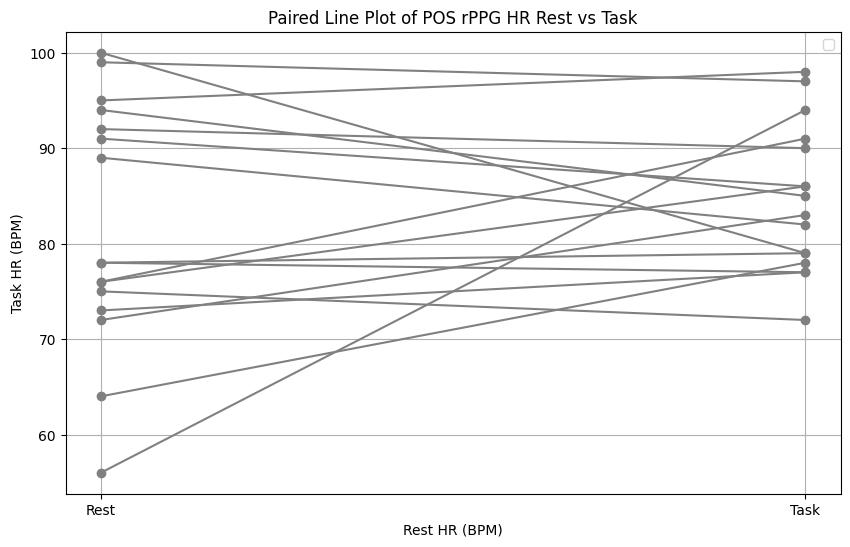

C:\Users\ACER\AppData\Local\Temp\ipykernel_11360\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


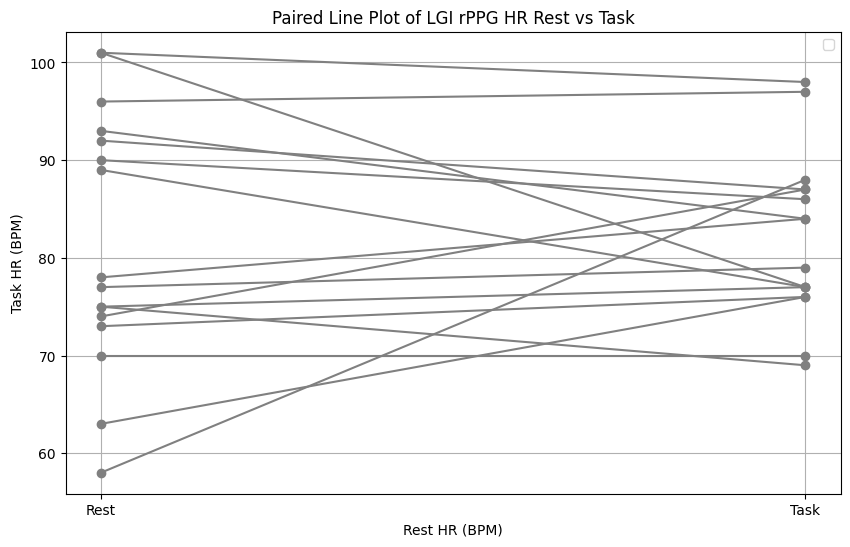

C:\Users\ACER\AppData\Local\Temp\ipykernel_11360\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


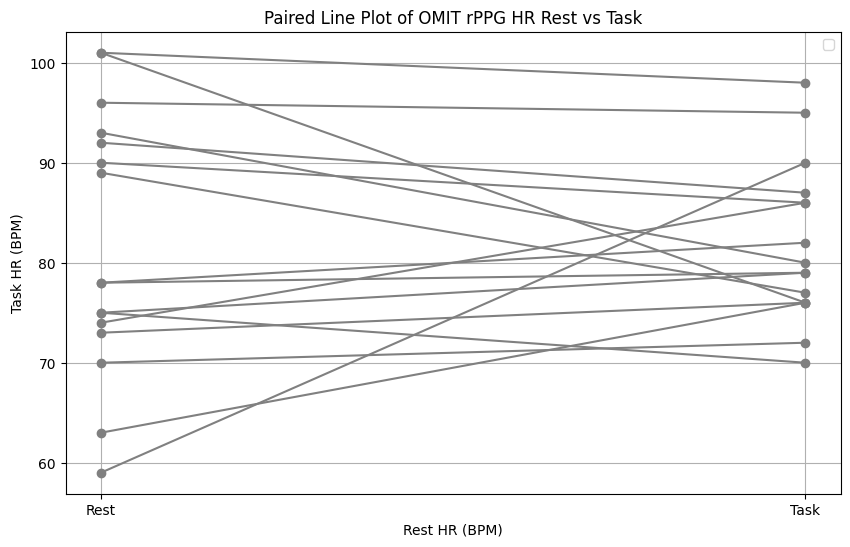

C:\Users\ACER\AppData\Local\Temp\ipykernel_11360\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


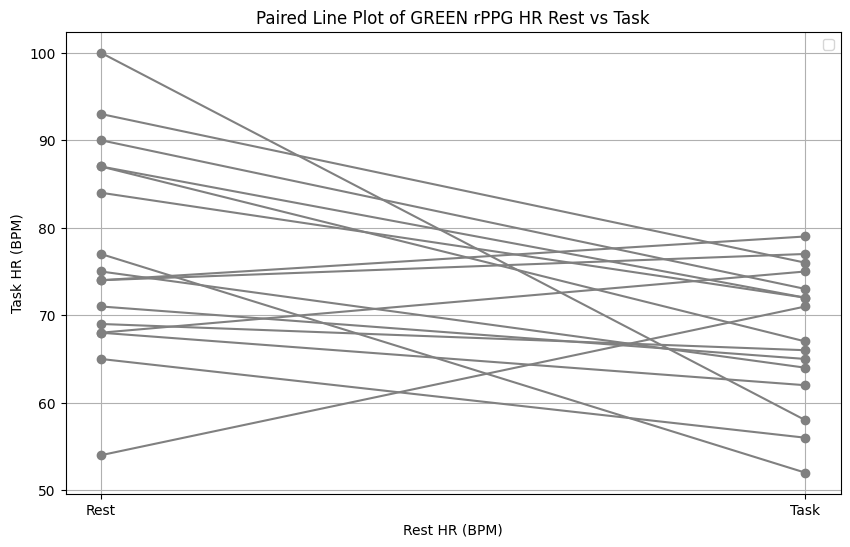

C:\Users\ACER\AppData\Local\Temp\ipykernel_11360\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


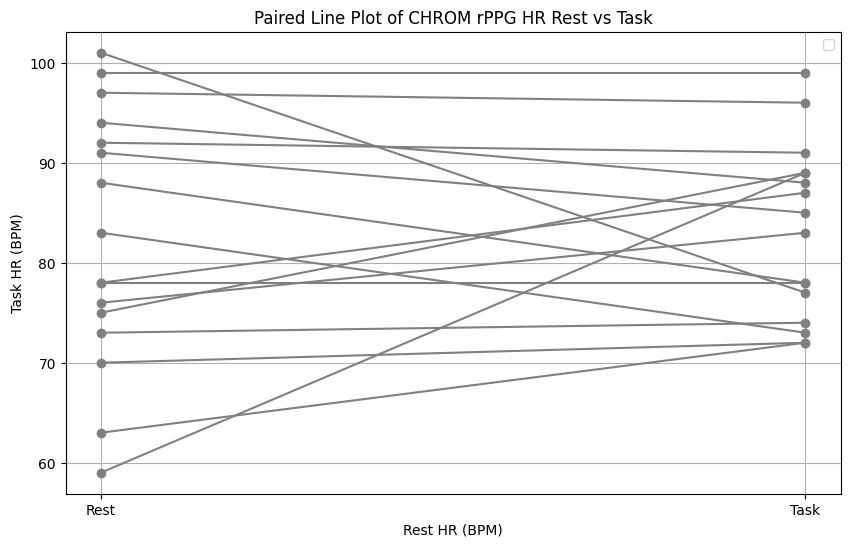

In [17]:
## Plot the paired line of the rPPG Rest vs Task HR
for method in rppg_rest.keys():
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])

    plt.figure(figsize=(10, 6))
    for i in range(len(rest)):
        plt.plot([0, 1], [rest[i], task[i]], marker='o', color='gray')
    plt.title(f"Paired Line Plot of {method} rPPG HR Rest vs Task")
    plt.xlabel("Rest HR (BPM)")
    plt.ylabel("Task HR (BPM)")
    plt.xticks([0, 1], ['Rest', 'Task'])
    plt.grid()
    plt.legend()    
    plt.show()


### Plot the paired line between the GT rest and GT Task

C:\Users\ACER\AppData\Local\Temp\ipykernel_11360\2976055994.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


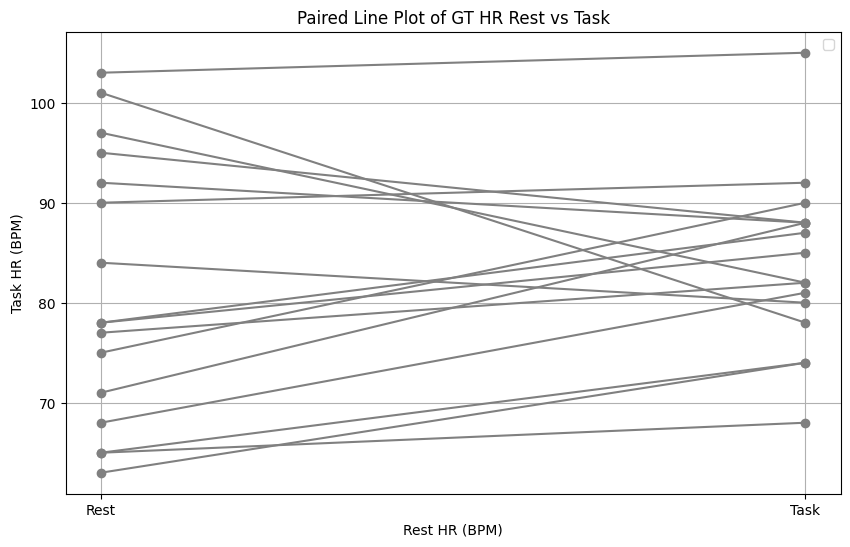

In [18]:
### Plot the paired line between the GT rest and GT Task
# Store the HR
gt_rest = np.array([calculate_hr(face_landmarker_gt_rest[i], face_landmarker_gt_rest[i])[0] for i in range(len(face_landmarker_gt_rest))])
gt_task = np.array([calculate_hr(face_landmarker_gt_task[i], face_landmarker_gt_rest[i])[0] for i in range(len(face_landmarker_gt_rest))])

plt.figure(figsize=(10, 6))
for i in range(len(gt_rest)):
    plt.plot([0, 1], [gt_rest[i], gt_task[i]], marker='o', color='gray')
plt.title("Paired Line Plot of GT HR Rest vs Task")
plt.xlabel("Rest HR (BPM)")
plt.ylabel("Task HR (BPM)")
plt.xticks([0, 1], ['Rest', 'Task'])
plt.grid()
plt.legend()    
plt.show()


    


### Compute the Pearson Correlation of rPPG Rest and Task compare to the PPG

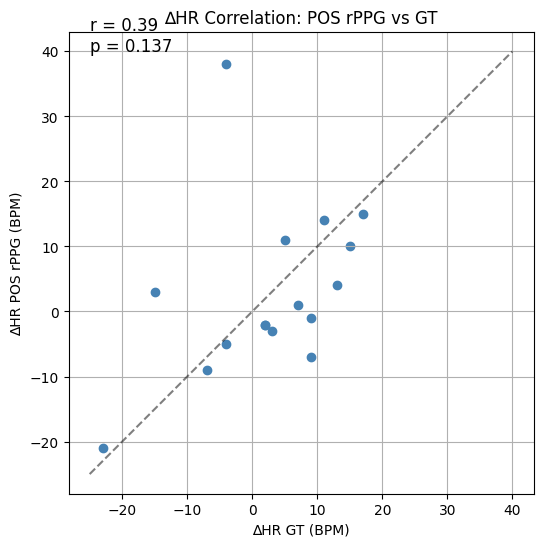

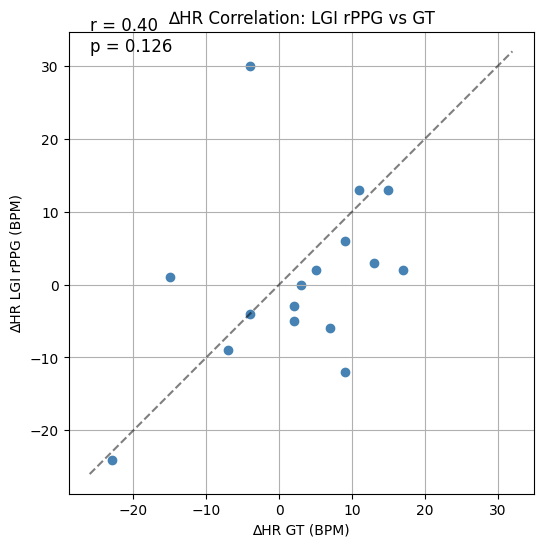

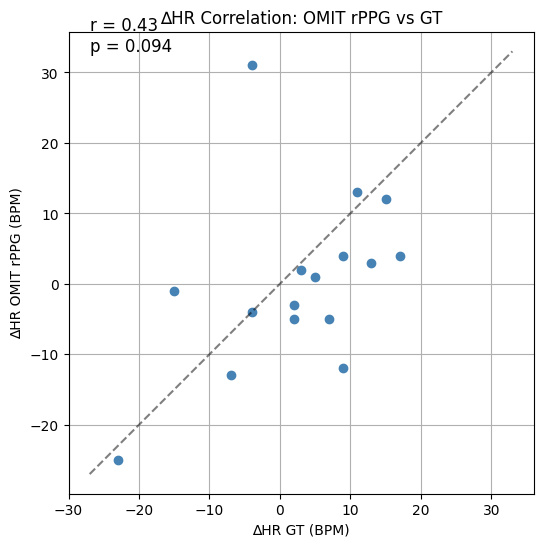

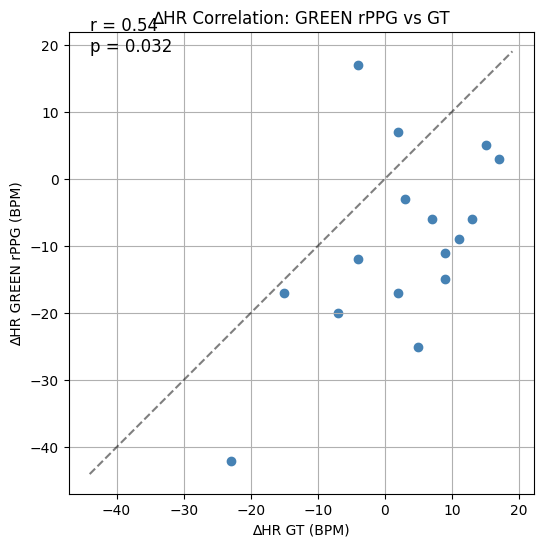

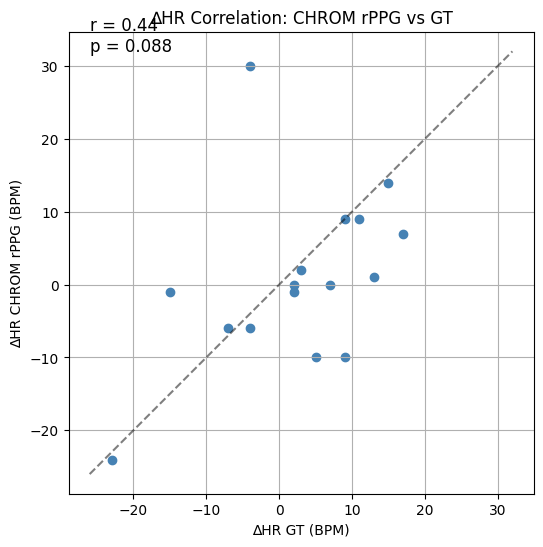

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Compute GT ∆HR per subject
delta_gt = gt_task - gt_rest  # Shape: (n_subjects,)

for method in rppg_rest.keys():
    # Get rPPG HR values for this method
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])
    
    # Compute ∆HR (task - rest)
    delta_rppg = task - rest

    # Plot correlation: ∆HR_rPPG vs ∆HR_GT
    plt.figure(figsize=(6, 6))
    plt.scatter(delta_gt, delta_rppg, color='steelblue')
    
    # Identity line
    lims = [min(min(delta_gt), min(delta_rppg)) - 2,
            max(max(delta_gt), max(delta_rppg)) + 2]
    plt.plot(lims, lims, 'k--', alpha=0.5)

    # Label
    plt.title(f"∆HR Correlation: {method} rPPG vs GT")
    plt.xlabel("∆HR GT (BPM)")
    plt.ylabel(f"∆HR {method} rPPG (BPM)")
    plt.grid(True)
    plt.axis('equal')

    # Pearson correlation
    r, p = pearsonr(delta_gt, delta_rppg)
    plt.text(lims[0], lims[1], f"r = {r:.2f}\np = {p:.3f}", fontsize=12)
    
    plt.show()



In [20]:
correlation_results = {}

for method in rppg_rest.keys():
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])
    delta_rppg = task - rest
    r, p = pearsonr(delta_gt, delta_rppg)
    correlation_results[method] = {'r': r, 'p': p}

# Create a DataFrame to display the correlation results
correlation_df = pd.DataFrame(correlation_results).T
correlation_df.index.name = 'Method'
correlation_df.reset_index(inplace=True)

# Display the df
print(correlation_results)

{'POS': {'r': 0.3886967943456642, 'p': 0.13677444337252143}, 'LGI': {'r': 0.3988029400674758, 'p': 0.12598788353280635}, 'OMIT': {'r': 0.43324898480809904, 'p': 0.09366400784832243}, 'GREEN': {'r': 0.5367786174475404, 'p': 0.032045501818048855}, 'CHROM': {'r': 0.4402007326170577, 'p': 0.0879369426778877}}


POS | ΔHR Correlation with GT: r = 0.389, p = 0.1368


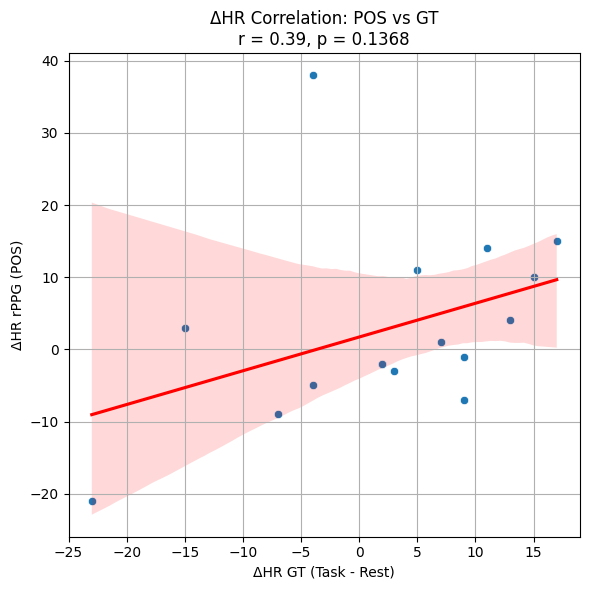

LGI | ΔHR Correlation with GT: r = 0.399, p = 0.1260


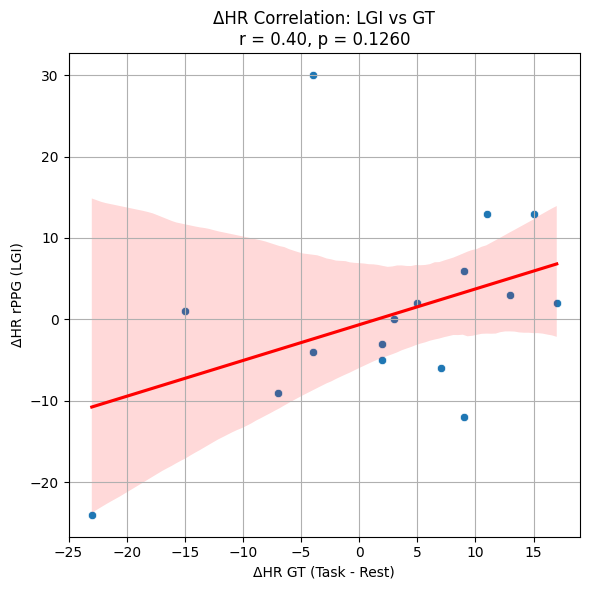

OMIT | ΔHR Correlation with GT: r = 0.433, p = 0.0937


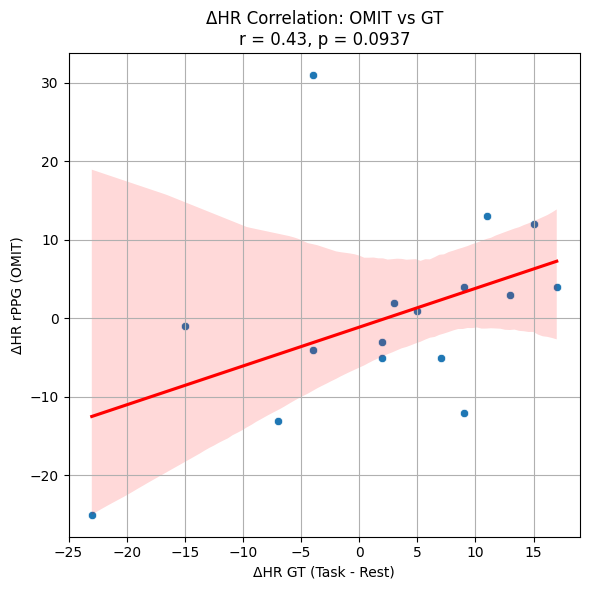

GREEN | ΔHR Correlation with GT: r = 0.537, p = 0.0320


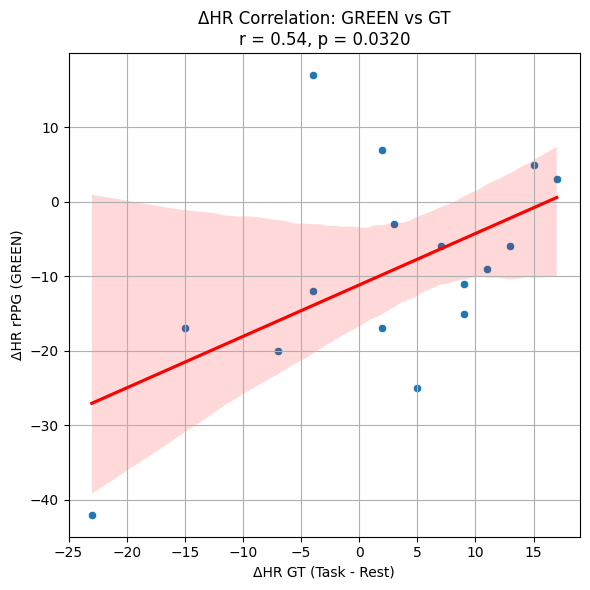

CHROM | ΔHR Correlation with GT: r = 0.440, p = 0.0879


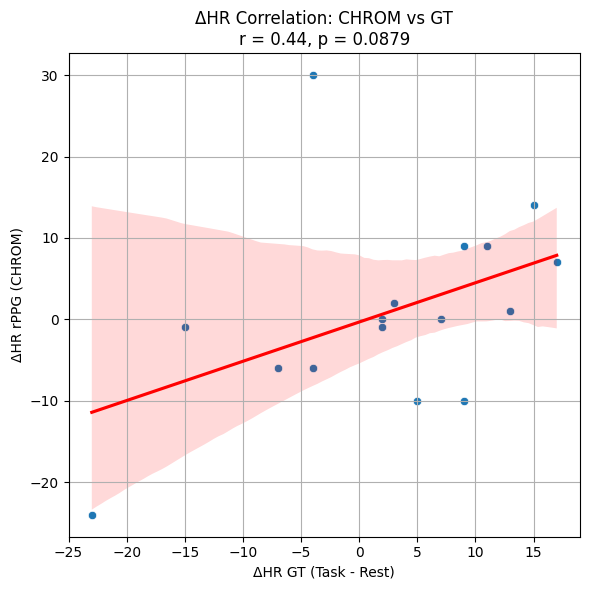

In [21]:
from scipy.stats import pearsonr
import seaborn as sns

# Delta HR GT
delta_gt = gt_task - gt_rest

for method in rppg_rest.keys():
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])
    delta_rppg = task - rest

    # Compute correlation
    r, p = pearsonr(delta_gt, delta_rppg)
    print(f"{method} | ΔHR Correlation with GT: r = {r:.3f}, p = {p:.4f}")

    # Scatter plot of delta
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=delta_gt, y=delta_rppg)
    sns.regplot(x=delta_gt, y=delta_rppg, scatter=False, color='red')
    plt.xlabel('ΔHR GT (Task - Rest)')
    plt.ylabel(f'ΔHR rPPG ({method})')
    plt.title(f'ΔHR Correlation: {method} vs GT\nr = {r:.2f}, p = {p:.4f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [22]:
for i in range(len(delta_gt)):
    print(f"Subject {i+1}: ΔGT = {delta_gt[i]:.2f}, Δ{method} = {delta_rppg[i]:.2f}")


Subject 1: ΔGT = -15.00, ΔCHROM = -1.00
Subject 2: ΔGT = 17.00, ΔCHROM = 7.00
Subject 3: ΔGT = -7.00, ΔCHROM = -6.00
Subject 4: ΔGT = 3.00, ΔCHROM = 2.00
Subject 5: ΔGT = 7.00, ΔCHROM = 0.00
Subject 6: ΔGT = 15.00, ΔCHROM = 14.00
Subject 7: ΔGT = 9.00, ΔCHROM = 9.00
Subject 8: ΔGT = 13.00, ΔCHROM = 1.00
Subject 9: ΔGT = -23.00, ΔCHROM = -24.00
Subject 10: ΔGT = 2.00, ΔCHROM = 0.00
Subject 11: ΔGT = 11.00, ΔCHROM = 9.00
Subject 12: ΔGT = -4.00, ΔCHROM = -6.00
Subject 13: ΔGT = 9.00, ΔCHROM = -10.00
Subject 14: ΔGT = 2.00, ΔCHROM = -1.00
Subject 15: ΔGT = -4.00, ΔCHROM = 30.00
Subject 16: ΔGT = 5.00, ΔCHROM = -10.00
